In [19]:
import pandas as pd
import numpy as np

print("📥 Loading raw corporate transaction logs...")
# Pointing to our local data directory
df=pd.read_excel("data/online_retail_II.xlsx") 

print(f"\n📊 DATABASE DIMENSIONS:")
print(f"➔ Total Row Records: {df.shape[0]:,}")
print(f"➔ Total Feature Columns: {df.shape[1]}")

print("\n🔍 DATA QUALITY AUDIT (Missing Values per Column):")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

print("\n📋 FIRST 5 TRANSACTIONS:")
df.head()

📥 Loading raw corporate transaction logs...

📊 DATABASE DIMENSIONS:
➔ Total Row Records: 525,461
➔ Total Feature Columns: 8

🔍 DATA QUALITY AUDIT (Missing Values per Column):
Description      2928
Customer ID    107927
dtype: int64

📋 FIRST 5 TRANSACTIONS:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [20]:
# ==========================================
# PHASE 1: CORPORATE DATA CLEANING
# ==========================================

# 1. Drop rows where Customer ID is missing
df_clean = df.dropna(subset=['Customer ID']).copy()

# 2. Ensure Customer ID is handled as a clean string for accurate referencing
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)

# 3. Create a calculated 'Total_Cost' column (Quantity * Price) for each individual line
df_clean['Total_Cost'] = df_clean['Quantity'] * df_clean['Price']

# 4. Filter out cancelled transactions
cancellations = df_clean[df_clean['Invoice'].astype(str).str.startswith('C') | (df_clean['Quantity'] <= 0)]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C') & (df_clean['Quantity'] > 0)]

print("🧹 PHASE 1 CLEANING COMPLETE:")
print(f"➔ Rows dropped due to missing Customer ID or Cancellations: {df.shape[0] - df_clean.shape[0]:,}")
print(f"➔ Remaining Clean Transaction Rows for Analysis: {df_clean.shape[0]:,}")
print(f"➔ Total Unique Customers Isolated: {df_clean['Customer ID'].nunique():,}")

🧹 PHASE 1 CLEANING COMPLETE:
➔ Rows dropped due to missing Customer ID or Cancellations: 117,766
➔ Remaining Clean Transaction Rows for Analysis: 407,695
➔ Total Unique Customers Isolated: 4,314


In [22]:
# Print out the first 5 rows of transactions that we caught and separated into 'cancellations'
print("🚫 EXAMPLES OF CANCELLED OR RETURNED TRANSACTIONS:")
cancellations.head()

🚫 EXAMPLES OF CANCELLED OR RETURNED TRANSACTIONS:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Cost
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia,-35.4


In [23]:
# ==========================================
# PHASE 2 UPGRADE: ADVANCED FEATURE ENGINEERING
# ==========================================

# 1. Ensure dates are properly formatted
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. Establish our simulated today snapshot date
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# 3. Advanced Aggregation Matrix
customer_df = df_clean.groupby('Customer ID').agg({
    # A. Recency: Days since last visit (Our Target metric)
    'InvoiceDate': [
        lambda x: (snapshot_date - x.max()).days,
        lambda x: (x.max() - x.min()).days  # B. Tenure: Total lifespan days at store
    ],
    # C. Frequency: Total unique orders placed
    'Invoice': 'nunique',
    # D. Product Diversity: Total unique item types bought
    'StockCode': 'nunique',
    # E. Monetary: Total cash spent
    'Total_Cost': 'sum',
    # F. Geography: Mark if international client
    'Country': lambda x: 1 if x.iloc[0] != 'United Kingdom' else 0
})

# 4. Flatten the multi-level columns generated by pandas aggregation
customer_df.columns = [
    'Recency_Days', 
    'Customer_Tenure_Days', 
    'Total_Orders', 
    'Unique_Items_Bought', 
    'Total_Spent', 
    'Is_International'
]

# 5. Calculate Average Order Value (Total Spent / Total Orders)
customer_df['Avg_Order_Value'] = customer_df['Total_Spent'] / customer_df['Total_Orders']

print("🏗️ UPGRADED CUSTOMER PROFILE TABLE CREATED:")
print(f"➔ Matrix Layout Shape (Customers x Features): {customer_df.shape}")
customer_df.head()

🏗️ UPGRADED CUSTOMER PROFILE TABLE CREATED:
➔ Matrix Layout Shape (Customers x Features): (4314, 7)


,Recency_Days,Customer_Tenure_Days,Total_Orders,Unique_Items_Bought,Total_Spent,Is_International,Avg_Order_Value
Customer ID,,,,,,,
12346,165,196,11,26,372.86,0,33.896364
12347,3,37,2,70,1323.32,1,661.660000
12348,74,0,1,20,222.16,1,222.160000
12349,43,181,3,90,2671.14,1,890.380000
12351,11,0,1,21,300.93,1,300.930000


In [25]:
# ==========================================
# PHASE 3 UPGRADE: MULTI-FEATURE TRAIN/TEST SPLIT
# ==========================================
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Re-apply our 90-day corporate rule to create the target label (y)
CHURN_THRESHOLD = 90
customer_df['Churn'] = np.where(customer_df['Recency_Days'] > CHURN_THRESHOLD, 1, 0)

# 2. Extract our UPGRADED feature matrix (X)
# We select all 6 behavioral columns and explicitly exclude 'Recency_Days' and 'Churn'
feature_cols = [
    'Customer_Tenure_Days', 
    'Total_Orders', 
    'Unique_Items_Bought', 
    'Total_Spent', 
    'Is_International', 
    'Avg_Order_Value'
]
X = customer_df[feature_cols]
y = customer_df['Churn']

# 3. Perform the 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 4. Scale all 6 features so they can compete fairly in the math engine
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("⚖️ UPGRADED FEATURE SPLIT COMPLETE:")
print(f"➔ Total Feature Clues Being Passed to AI: {X_train_scaled.shape[1]}")
print(f"➔ Columns: {', '.join(feature_cols)}")
print(f"➔ Training Sample Profiles: {X_train_scaled.shape[0]}")

⚖️ UPGRADED FEATURE SPLIT COMPLETE:
➔ Total Feature Clues Being Passed to AI: 6
➔ Columns: Customer_Tenure_Days, Total_Orders, Unique_Items_Bought, Total_Spent, Is_International, Avg_Order_Value
➔ Training Sample Profiles: 3451


In [9]:
X_train_scaled[0]

array([0.64170365, 0.12818604])

In [26]:
# ==========================================
# PHASE 4 UPGRADE: MODEL TRAINING & AUDIT
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize our Random Forest panel using our 6-feature layout
model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)

# 2. Train the model on the expanded training features
print("🧠 Training the Upgraded Random Forest Engine with 6 Clues...")
model.fit(X_train_scaled, y_train)

# 3. Predict blind guesses on the hidden exam set
y_pred = model.predict(X_test_scaled)

print("\n📊 UPGRADED MODEL PERFORMANCE EVALUATION REPORT:")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred))

print("📋 UPGRADED CONFUSION MATRIX GRID:")
print(confusion_matrix(y_test, y_pred))

🧠 Training the Upgraded Random Forest Engine with 6 Clues...

📊 UPGRADED MODEL PERFORMANCE EVALUATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       576
           1       0.55      0.43      0.48       287

    accuracy                           0.69       863
   macro avg       0.65      0.63      0.63       863
weighted avg       0.68      0.69      0.68       863

📋 UPGRADED CONFUSION MATRIX GRID:
[[475 101]
 [163 124]]


🏆 THE ULTIMATE BUSINESS CLUE LEADERBOARD:
--------------------------------------------------
             Feature  Importance_Score
         Total_Spent          0.252277
Customer_Tenure_Days          0.247746
 Unique_Items_Bought          0.212476
     Avg_Order_Value          0.212438
        Total_Orders          0.062592
    Is_International          0.012470


C:\Users\mrina\AppData\Local\Temp\ipykernel_28072\4139494164.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=importance_df, palette='viridis')
C:\Users\mrina\AppData\Local\Temp\ipykernel_28072\4139494164.py:27: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mrina\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


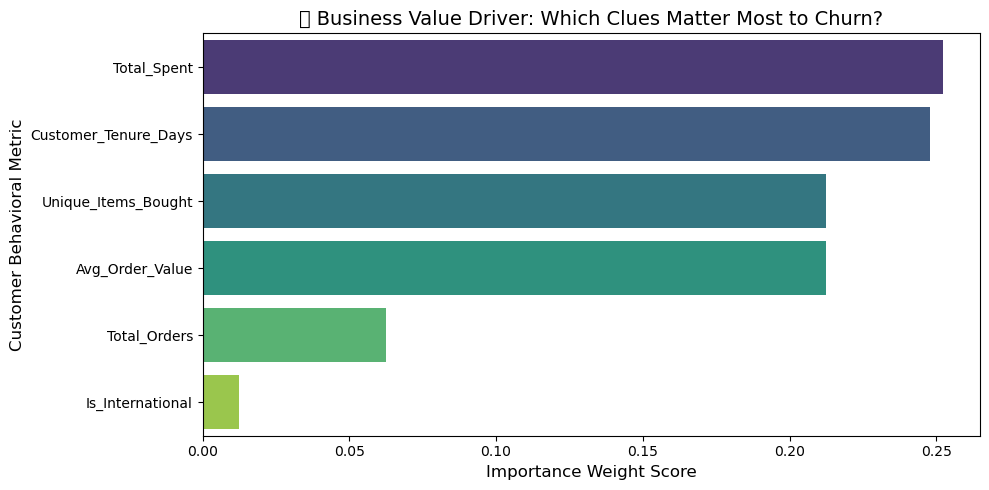

In [27]:
# ==========================================
# PHASE 5: FEATURE IMPORTANCE EXTRACTION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the raw importance scores from our trained brain
importances = model.feature_importances_

# 2. Match the numbers up with our 6 column names
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

print("🏆 THE ULTIMATE BUSINESS CLUE LEADERBOARD:")
print("--------------------------------------------------")
print(importance_df.to_string(index=False))

# 3. Plot a clean corporate bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance_Score', y='Feature', data=importance_df, palette='viridis')
plt.title('🔥 Business Value Driver: Which Clues Matter Most to Churn?', fontsize=14)
plt.xlabel('Importance Weight Score', fontsize=12)
plt.ylabel('Customer Behavioral Metric', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# PHASE 6: EXPORTING THE MODEL FOR PRODUCTION
# ==========================================
import joblib

# Save the trained Random Forest brain to a file
joblib.dump(model, 'churn_random_forest_model.pkl')

# Save the scaler so new data can be normalized the exact same way
joblib.dump(scaler, 'churn_data_scaler.pkl')

print("💾 ARCHIVING COMPLETE:")
print("➔ 'churn_random_forest_model.pkl' saved to your project folder!")
print("➔ 'churn_data_scaler.pkl' saved to your project folder!")

💾 ARCHIVING COMPLETE:
➔ 'churn_random_forest_model.pkl' saved to your project folder!
➔ 'churn_data_scaler.pkl' saved to your project folder!


In [1]:
# ==========================================
# EXPORTING THE MODEL COMPONENTS FOR THE APP
# ==========================================
import joblib

# 1. Freeze the trained Random Forest brain to a permanent file
joblib.dump(model, 'churn_random_forest_model.pkl')

# 2. Freeze the scaler so the app can normalize data the exact same way
joblib.dump(scaler, 'churn_data_scaler.pkl')

print("💾 ARCHIVING COMPLETE:")
print("➔ 'churn_random_forest_model.pkl' saved to your project folder!")
print("➔ 'churn_data_scaler.pkl' saved to your project folder!")

NameError: name 'model' is not defined

In [32]:
# Save the first 1,000 rows of your clean data as a test file
df_clean.head(1000).to_csv('test_transactions.csv', index=False)
print("✨ Created 'test_transactions.csv' in your folder! Drag and drop this into your browser.")

✨ Created 'test_transactions.csv' in your folder! Drag and drop this into your browser.
